In [ ]:
import nibabel as nib
import numpy as np
from pathlib import Path
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from dotenv import dotenv_values, find_dotenv
import sys
from helper import get_filepath, format_index


config = dotenv_values(find_dotenv(usecwd=True))
TR_DATA_PATH = Path(config.get("TR_DATA_PATH"))

In [2]:

def print_extra_data(img: nib.Nifti1Image):
    affine = img.affine
    voxel_size = np.sqrt((affine[:3, :3]**2)).sum(axis=0)
    print(affine)
    print(voxel_size)


In [3]:
modalities = ["t1", "t1ce", "t2", "flair", "seg"]
cmap = ListedColormap([
    "black",  # background
    "red",    # necrotic
    "green",  # edema
    "yellow"  # enhancing tumor
])

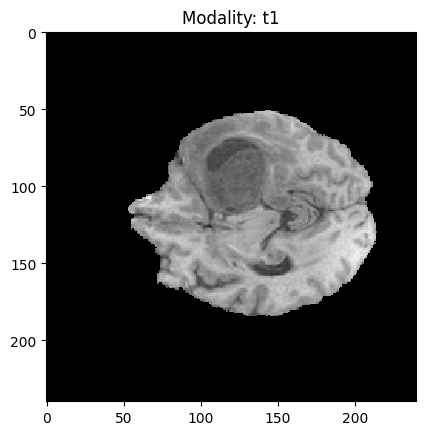

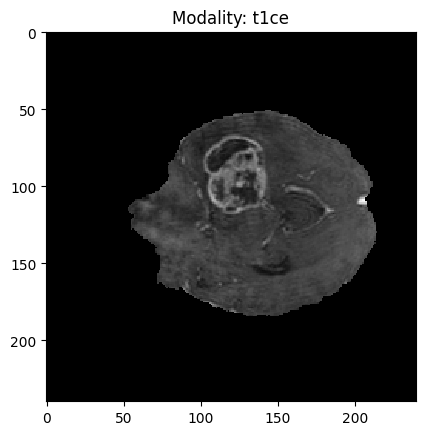

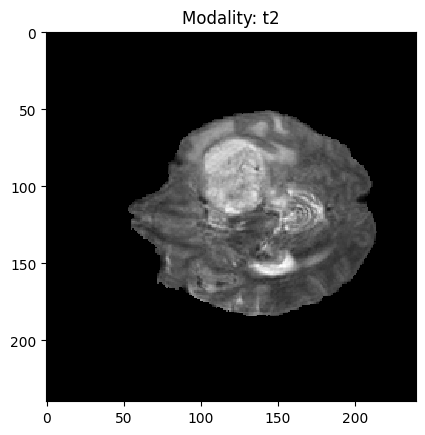

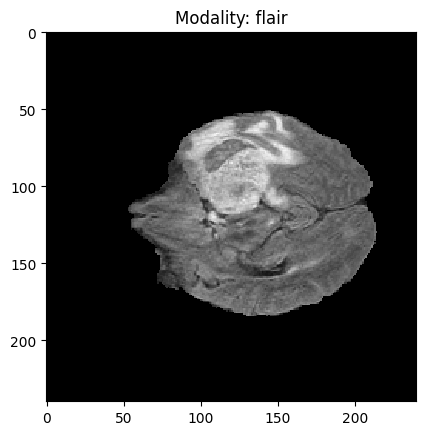

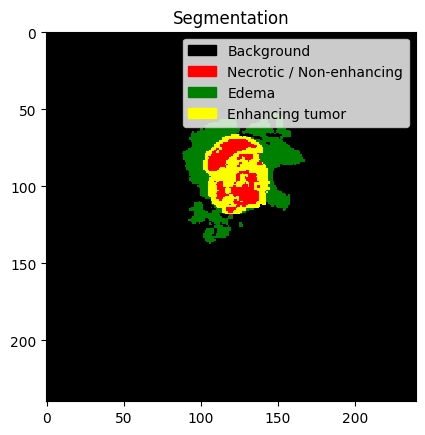

In [ ]:
def visualize_brain(brain_index, slice_index):
    for mod in modalities:
        path = get_filepath(brain_index, mod)
        img = nib.load(path)


        brain = img.get_fdata() # loads 3D voxels into a NumPy array?
        brain_slice = brain[:, :, slice_index] # height, width, depth

        if mod != "seg":
            plt.imshow(brain_slice, cmap="gray", interpolation='nearest')
            plt.title(f"Modality: {mod}")
            plt.show()
            continue
        
        # we relabel the data as lable 3 is "missing pixel" and there are no pixels missing
        brain_slice[brain_slice == 4] = 3 

        patches = [
            mpatches.Patch(color="black", label="Background"),
            mpatches.Patch(color="red", label="Necrotic / Non-enhancing"),
            mpatches.Patch(color="green", label="Edema"),
            mpatches.Patch(color="yellow", label="Enhancing tumor"),
        ]
        plt.imshow(brain_slice, cmap=cmap, interpolation="nearest")
        plt.legend(handles=patches, loc="upper right")
        plt.title("Segmentation")
        plt.show()

visualize_brain(1, 59)
